# Задание 1. Пропущенные значения и корреляции

## 1. Создание синтетического датасета  
Используя функцию multivariate_normal из numpy с любым random_state,
сгенерировать и зафиксировать датасет dfS00, в котором есть четыре количественных
(недискретных) признака и 1 класс размером 1000 объектов, для одной пары признаков
(A и B) которого задана корреляция r=+0.9, а остальные признаки не сопряжены друг с
другом.

In [9]:
import numpy as np
import pandas as pd

# Типо нормальное распределение

mean = [0, 0, 0, 0]  # средние значения
cov = [
    [1.0, 0.9, 0.0, 0.0],  # A коррелирует с B
    [0.9, 1.0, 0.0, 0.0],  # B коррелирует с A
    [0.0, 0.0, 1.0, 0.0],  # C независим
    [0.0, 0.0, 0.0, 1.0]   # D независим
] 

np.random.seed(42)  # фиксируем random_state
data = np.random.multivariate_normal(mean, cov, size=1000) # генерирует выборку из многомерного нормального распределения
dfS00 = pd.DataFrame(data, columns=['A', 'B', 'C', 'D'])
dfS00['class'] = 1  # один класс
display(dfS00.head(5))

,A,B,C,D,class
0,-0.824697,-0.143577,0.647689,-0.138264,1
1,0.056621,0.399828,1.579213,-0.234137,1
2,0.561727,0.353447,-0.463418,0.542560,1
3,-0.110104,-0.361567,-1.724918,-1.913280,1
4,1.302986,0.671385,-0.908024,0.314247,1


## 2. Статистика по датасету
Вывести в табличной форме статистику по датасету:
- Размерность всего датасета (объекты и признаки)  
- Тип каждого признака 
- Количество классов и объектов в каждом из классов  
- Иные оценки выборки 
- Число объектов с NaN по классам  
- Число объектов с 0 по классам 

In [3]:
# Размерность всего датасета (объекты и признаки) 
print(f'Размерность датасета: {dfS00.shape}\n')


# Тип каждого признака
print(f'Тип каждого признака: \n{dfS00.dtypes}\n')


# Количество классов и объектов в каждом из классов
counts = dfS00['class'].value_counts().sort_index()
print('Количество классов:', dfS00['class'].nunique())
print('Объектов в каждом классе:')
print(f'{counts}\n')


# Иные оценки выборки
def describe_extended(series):
    x = series.values
    
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1

    return pd.Series({
        'mean': np.mean(x),
        'median': np.median(x),
        'std': np.std(x, ddof=1),
        'var': np.var(x, ddof=1),
        'min': np.min(x),
        'max': np.max(x),
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
    })
stats_table = dfS00.drop(columns=['class']).apply(describe_extended)
print('Различные оценки выборки: ')
print(stats_table.T.round(3), '\n')

Размерность датасета: (1000, 5)

Тип каждого признака: 
A        float64
B        float64
C        float64
D        float64
class      int64
dtype: object

Количество классов: 1
Объектов в каждом классе:
class
1    1000
Name: count, dtype: int64

Различные оценки выборки: 
    mean  median    std    var    min    max     q1     q3    iqr
A -0.037  -0.039  0.961  0.924 -3.137  3.198 -0.657  0.600  1.257
B -0.023  -0.032  0.971  0.943 -3.185  3.220 -0.693  0.600  1.293
C -0.008  -0.008  1.006  1.012 -3.241  3.152 -0.675  0.642  1.318
D  0.025   0.020  1.012  1.024 -2.896  3.853 -0.677  0.694  1.371 



In [4]:
# Число объектов с NaN по классам
print('Число объектов с NaN по классам: ')
print(dfS00.groupby('class').apply(lambda g: g.isna().any(axis=1).sum()))


# Число объектов с 0 по классам
print('\nЧисло объектов с 0 по классам: ')
features = [c for c in dfS00.columns if c != 'class']
print(dfS00.groupby('class')[features].apply(lambda g: (g == 0).any(axis=1).sum()))


Число объектов с NaN по классам: 
class
1    0
dtype: int64

Число объектов с 0 по классам: 
class
1    0
dtype: int64


## 3. Визуализация статистики в 1D
- Выполнить 1D визуализацию датасета по каждому из признаков в форме raincloud plot with jittering,
- В виде boxplot отобразить медианы, межквартильные размахи (IQR) и размахи (Range), с параметрами boxplot, которые можно заменять на другие оценки выборки.

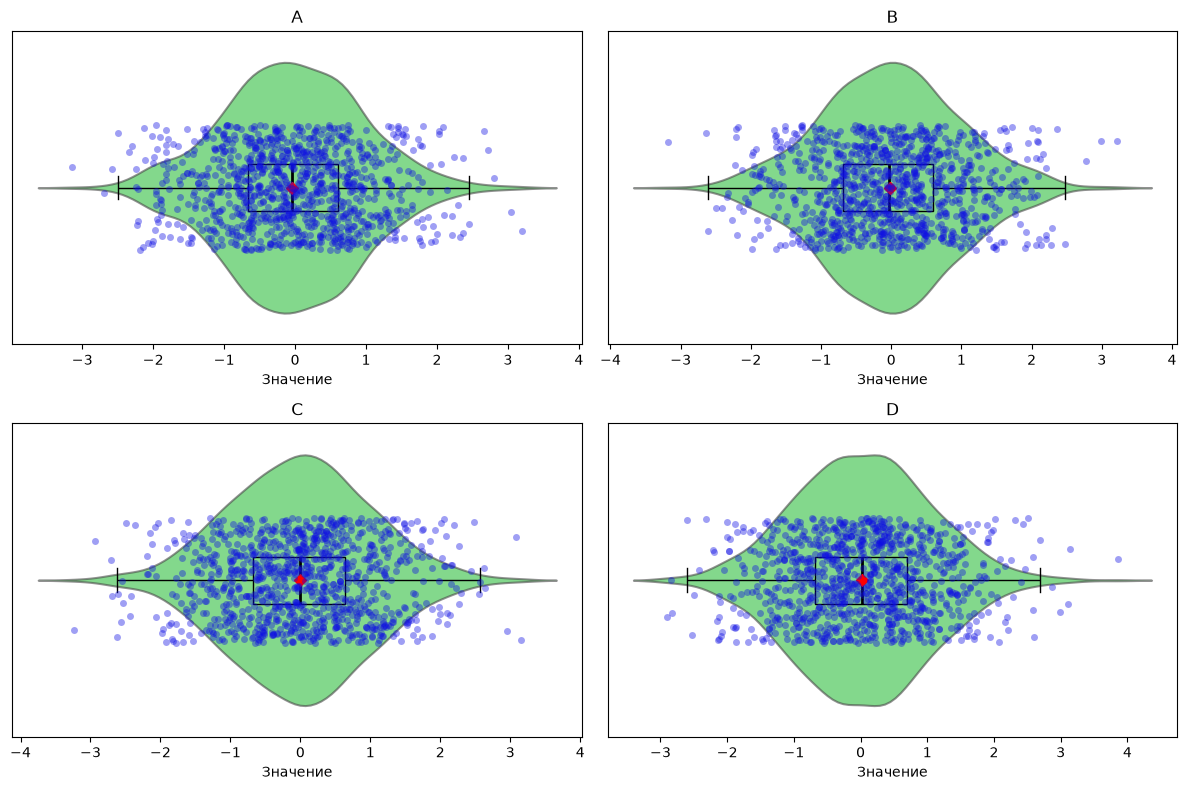

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_raincloud(df, feature, ax, whis=1.5, show_mean=True):
    sns.violinplot(x=df[feature], ax=ax, color='#19D62C', alpha=.6, inner=None, linewidth=1.5)
    sns.stripplot(x=df[feature], ax=ax, color='#0F0FE4', alpha=.4, size=5, jitter=.2)
    sns.boxplot(x=df[feature], ax=ax, width=.15, whis=whis, showfliers=False, showmeans=show_mean,
                meanprops={'marker':'D','markerfacecolor':'red','markeredgecolor':'red','markersize':6},
                medianprops={'color':'black','linewidth':2}, boxprops={'facecolor':'none','edgecolor':'black'},
                whiskerprops={'color':'black'}, capprops={'color':'black'})
    ax.set_title(feature)
    ax.set_xlabel('Значение')
    ax.set_yticks([])

features = ['A', 'B', 'C', 'D']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flat, features):
    plot_raincloud(dfS00, feature, ax, whis=1.5)

plt.tight_layout()
plt.show()

## 4. Вызуализация статистики в 2D
Выполнить  2D  визуализацию  датасета  по  всем  парам  выбранных  переменных  с использованием scatterplot с параметрами визуализации, регулируемыми пользователем:
1. Цвета  и  толщины  осей
2. Число/шаг  больших  и  малых  рисок  осей
3. Сетка  пространства
4. Квадратность  формы  каждого  рисунка
5. Размер  и  тип  шрифтов  каждого  типа  подписей
6. Отключаемость легенд и заглавий
7. Прозрачность объектов, на которых отображены: 
- на графиках разных пар признаков объекты классов разными по форме/цвету точками
- на графиках с одной и той же парой переменных 
- диаграммы плотности распределения каждого класса по оси признака разными по цвету/прозрачности.

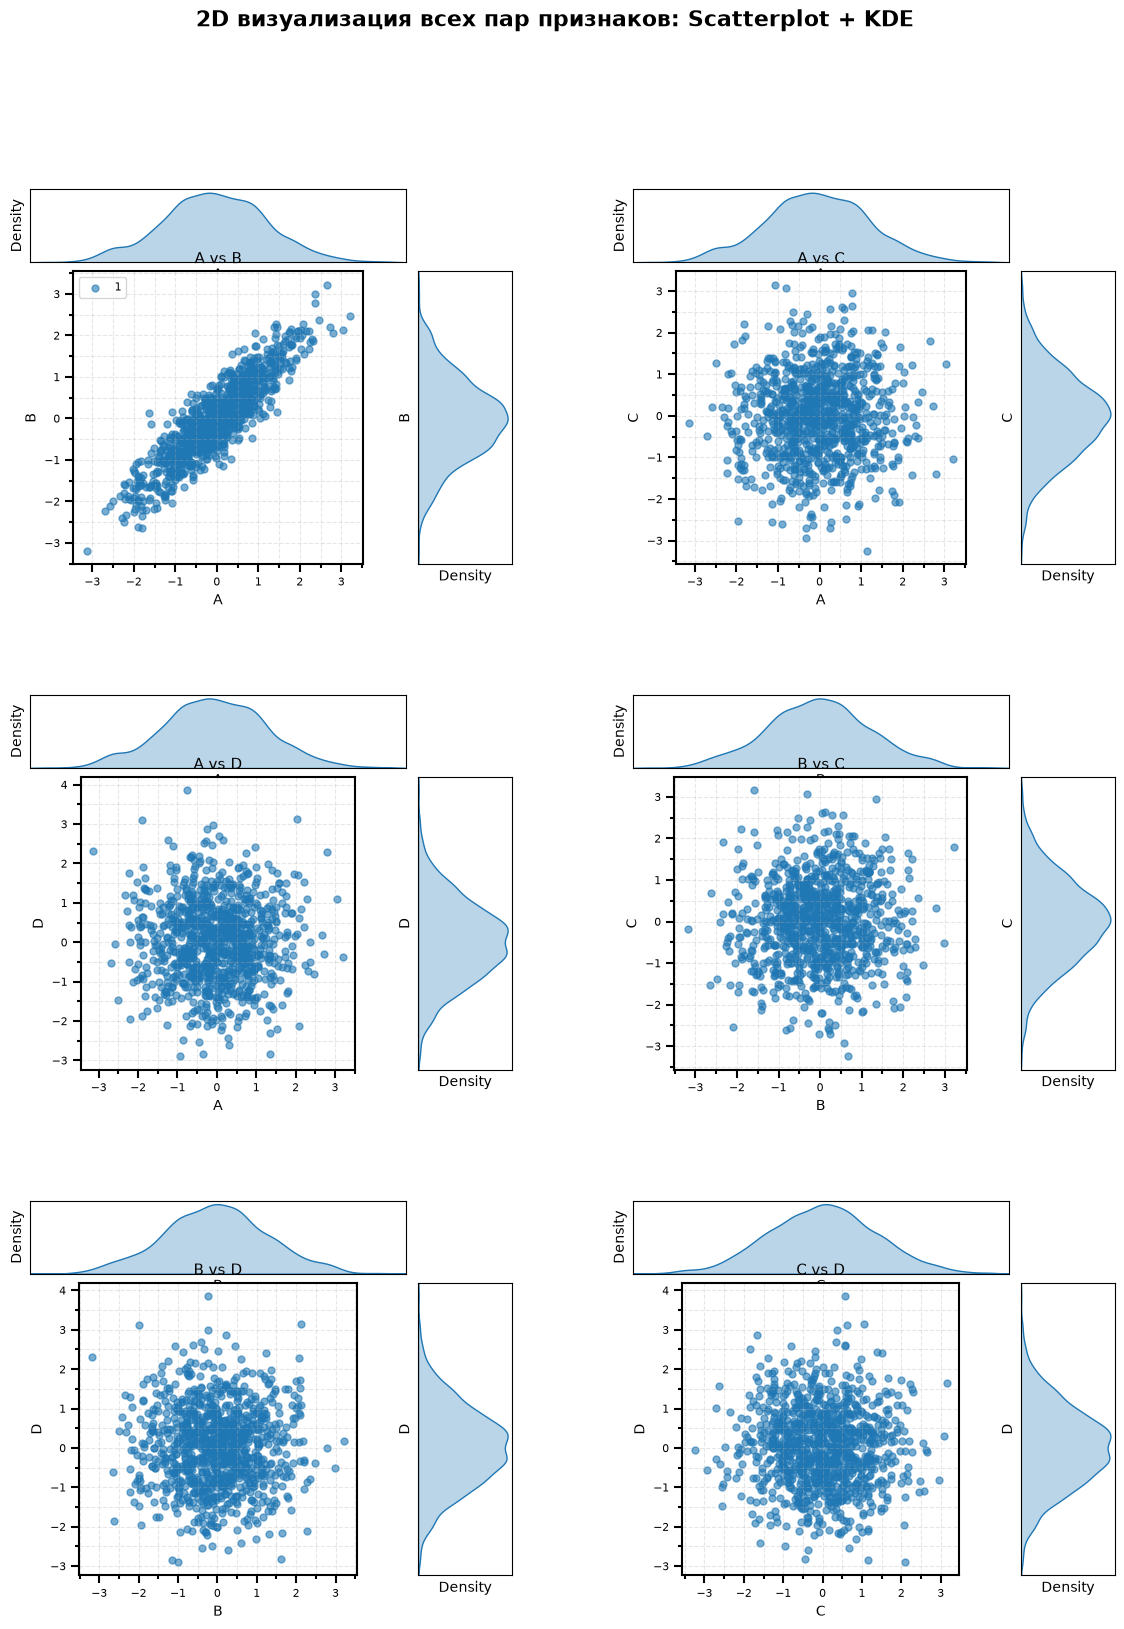

In [14]:
from itertools import combinations
from matplotlib.ticker import MultipleLocator

def plot_pair(df, x, y, ax, ax_x, ax_y, point_colors=None, point_markers=None, point_size=30, point_alpha=.6,
              axis_color='black', axis_width=1.5, major_step=1, minor_step=.5, show_grid=True, aspect_equal=True,
              show_title=True, show_legend=False, title_size=12, label_size=10, tick_size=9,
              font='sans-serif', kde_alpha=.3, kde_bw=.8):

    classes = df['class'].unique()
    colors = point_colors or sns.color_palette('tab10', len(classes))
    markers = point_markers or ['o', 's', '^', 'D', 'v'][:len(classes)]

    for i, cls in enumerate(classes):
        d = df[df['class'] == cls]
        ax.scatter(d[x], d[y], color=colors[i], marker=markers[i], s=point_size, alpha=point_alpha, label=str(cls))
        sns.kdeplot(x=d[x], ax=ax_x, color=colors[i], fill=True, alpha=kde_alpha, bw_adjust=kde_bw)
        sns.kdeplot(y=d[y], ax=ax_y, color=colors[i], fill=True, alpha=kde_alpha, bw_adjust=kde_bw)

    ax.set_xlabel(x, fontsize=label_size, fontfamily=font)
    ax.set_ylabel(y, fontsize=label_size, fontfamily=font)
    if show_title: ax.set_title(f'{x} vs {y}', fontsize=title_size, fontfamily=font)
    if show_legend: ax.legend(fontsize=tick_size)
    if aspect_equal: ax.set_aspect('equal', adjustable='box')

    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_locator(MultipleLocator(major_step))
        axis.set_minor_locator(MultipleLocator(minor_step))

    ax.tick_params(axis='both', which='major', length=6, width=axis_width, labelsize=tick_size, colors=axis_color)
    ax.tick_params(axis='both', which='minor', length=3, width=axis_width, colors=axis_color)

    for spine in ax.spines.values():
        spine.set_color(axis_color)
        spine.set_linewidth(axis_width)

    if show_grid: ax.grid(True, which='both', alpha=.3, linestyle='--')

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(font)

    # Убираем подписи на KDE
    ax_x.set_xlim(ax.get_xlim()); ax_x.set_xticks([]); ax_x.set_yticks([])
    ax_y.set_ylim(ax.get_ylim()); ax_y.set_xticks([]); ax_y.set_yticks([])


features = ['A', 'B', 'C', 'D']
pairs = list(combinations(features, 2))

fig = plt.figure(figsize=(14, 18))
outer = fig.add_gridspec(3, 2, hspace=.35, wspace=.25)

for i, (x, y) in enumerate(pairs):
    gs = outer[i].subgridspec(2, 2, height_ratios=[1, 4], width_ratios=[4, 1], hspace=.05, wspace=.05)
    ax_x = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    ax_y = fig.add_subplot(gs[1, 1])

    plot_pair(dfS00, x, y, ax, ax_x, ax_y, point_size=25, point_alpha=.6,
              axis_color='black', axis_width=1.5, major_step=1, minor_step=.5,
              show_grid=True, aspect_equal=True, show_title=True, show_legend=(i == 0),
              title_size=11, label_size=10, tick_size=8, font='sans-serif', kde_alpha=.3, kde_bw=.8)

fig.suptitle('2D визуализация всех пар признаков: Scatterplot + KDE', fontsize=16, fontweight='bold')
plt.show()

## 5. Оценка степени сопряженности
Используя  коэффициенты  корреляции  Пирсона  и  Спирмана,  в  форме  heat-map таблицы оценить степень сопряженности пар признаков-переменных: 
- на всем датасете    
- в каждом отдельном классе датасета

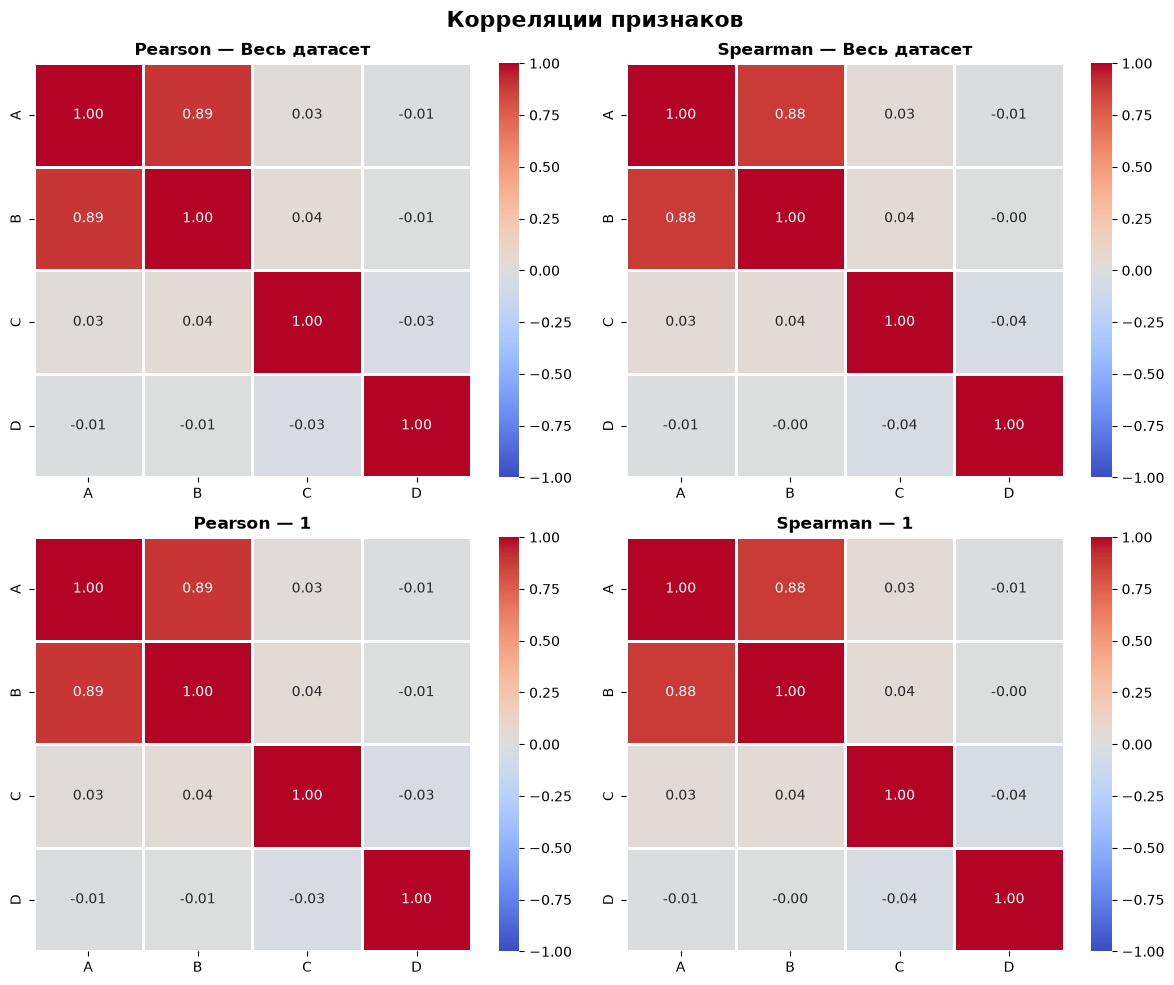

Пирсон:


,A,B,C,D
A,1.000,0.891,0.029,-0.009
B,0.891,1.000,0.045,-0.007
C,0.029,0.045,1.000,-0.032
D,-0.009,-0.007,-0.032,1.000


Спирман:


,A,B,C,D
A,1.000,0.876,0.032,-0.012
B,0.876,1.000,0.043,-0.001
C,0.032,0.043,1.000,-0.042
D,-0.012,-0.001,-0.042,1.000


In [15]:
def plot_correlation_heatmaps(df, features):
    groups = [('Весь датасет', df)] + list(df.groupby('class'))

    fig, axes = plt.subplots(len(groups), 2, figsize=(12, 5 * len(groups)))
    axes = np.atleast_2d(axes)

    for i, (name, data) in enumerate(groups):
        for j, method in enumerate(['pearson', 'spearman']):
            corr = data[features].corr(method=method)
            sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                        fmt='.2f', linewidths=1, linecolor='white', ax=axes[i, j])
            axes[i, j].set_title(f'{method.capitalize()} — {name}', fontsize=12, fontweight='bold')

    fig.suptitle('Корреляции признаков', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()


# [1.5] Корреляции на всём датасете и в каждом классе
plot_correlation_heatmaps(dfS00, features)

# Числовая сводка для отчёта
print('Пирсон:')
display(dfS00[features].corr(method='pearson').round(3))

print('Спирман:')
display(dfS00[features].corr(method='spearman').round(3))


## 6. Случайное удаление значения
- На  основе  исходного  датасета  dfS00 клонировать набор  датасетов dfSdXX,  в которых из  исходного  датасета  случайным  образом  удалено  значение  заданного пользователем  числа  ячеек  (0%,  1%,  2%,  5%,  10%,  20%,  50%,  80%)
- Для  выбираемой пары признаков (исходно A+B)  визуализировать каждый датасет dfSdXX  как панно mxn рисунков scatterplot. 

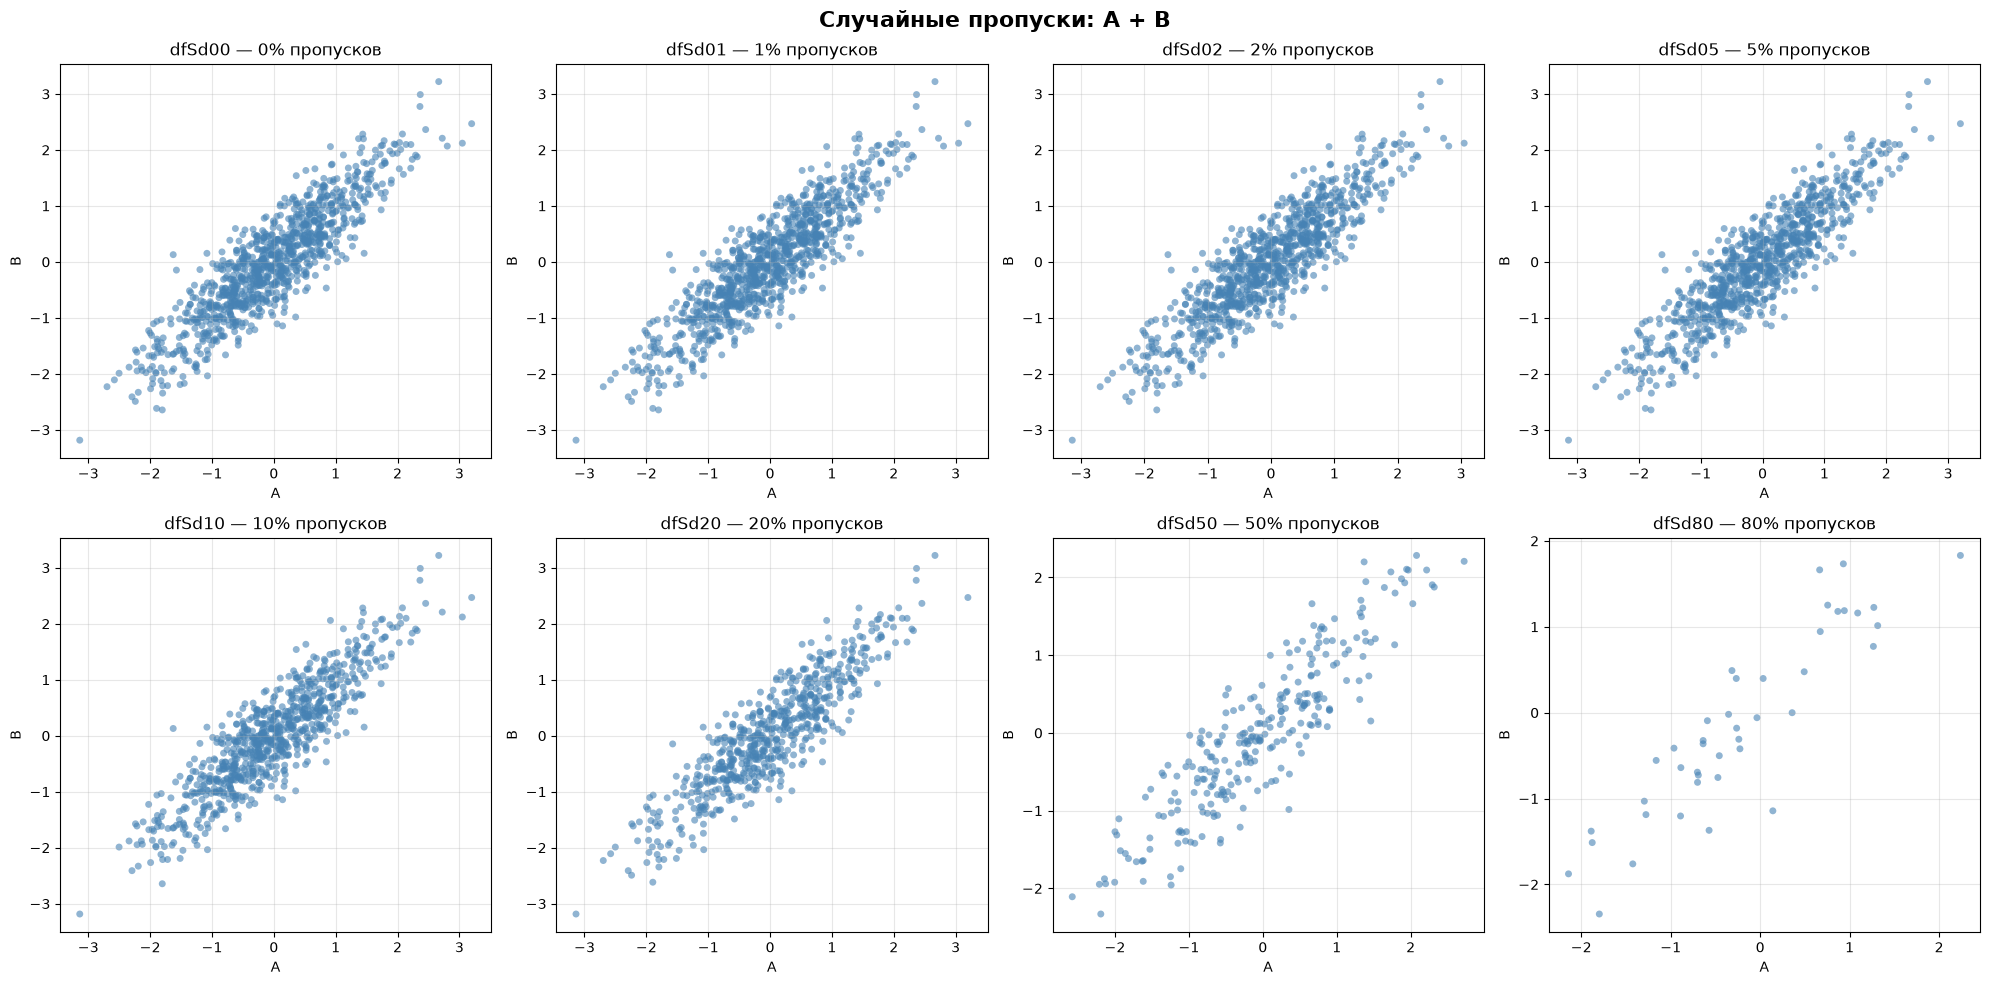

In [18]:
def add_random_missing_values(df, percent, features):
    df_out = df.copy()
    n_rows, n_cols = len(df), len(features)
    n = int(n_rows * n_cols * percent / 100)

    if n:
        idx = np.random.choice(n_rows * n_cols, n, replace=False)
        for i in idx:
            df_out.iat[i // n_cols, df.columns.get_loc(features[i % n_cols])] = np.nan

    return df_out


# Создаём dfSdXX для всех заданных процентов
percentages = [0, 1, 2, 5, 10, 20, 50, 80]
features = ['A', 'B', 'C', 'D']

datasets = {f'dfSd{p:02d}': add_random_missing_values(dfS00, p, features)
            for p in percentages}


# Панно 2×4 для выбранной пары A+B
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Случайные пропуски: A + B', fontsize=16, fontweight='bold')

for ax, (name, df), p in zip(axes.flat, datasets.items(), percentages):
    sns.scatterplot(data=df, x='A', y='B', ax=ax, s=25, alpha=.6,
                    color='steelblue', edgecolor='none')
    ax.set_title(f'{name} — {p}% пропусков')
    ax.grid(True, alpha=.3)

plt.tight_layout()
plt.show()

## 7. Заполнение пропусков
- На  основе всех  датасетов  dfSdXX сгенерировать  соответствующие  датасеты dfSdXXmed,  в которых пропуски заполнены медианой
- Для выбираемой пары признаков (исходно  A+B)  визуализировать  панно  mxn  рисунков  scatterplot  для  всех  dfSdXXmed  и вывести как heatmap корреляции Пирсона как в пункте [1.5]

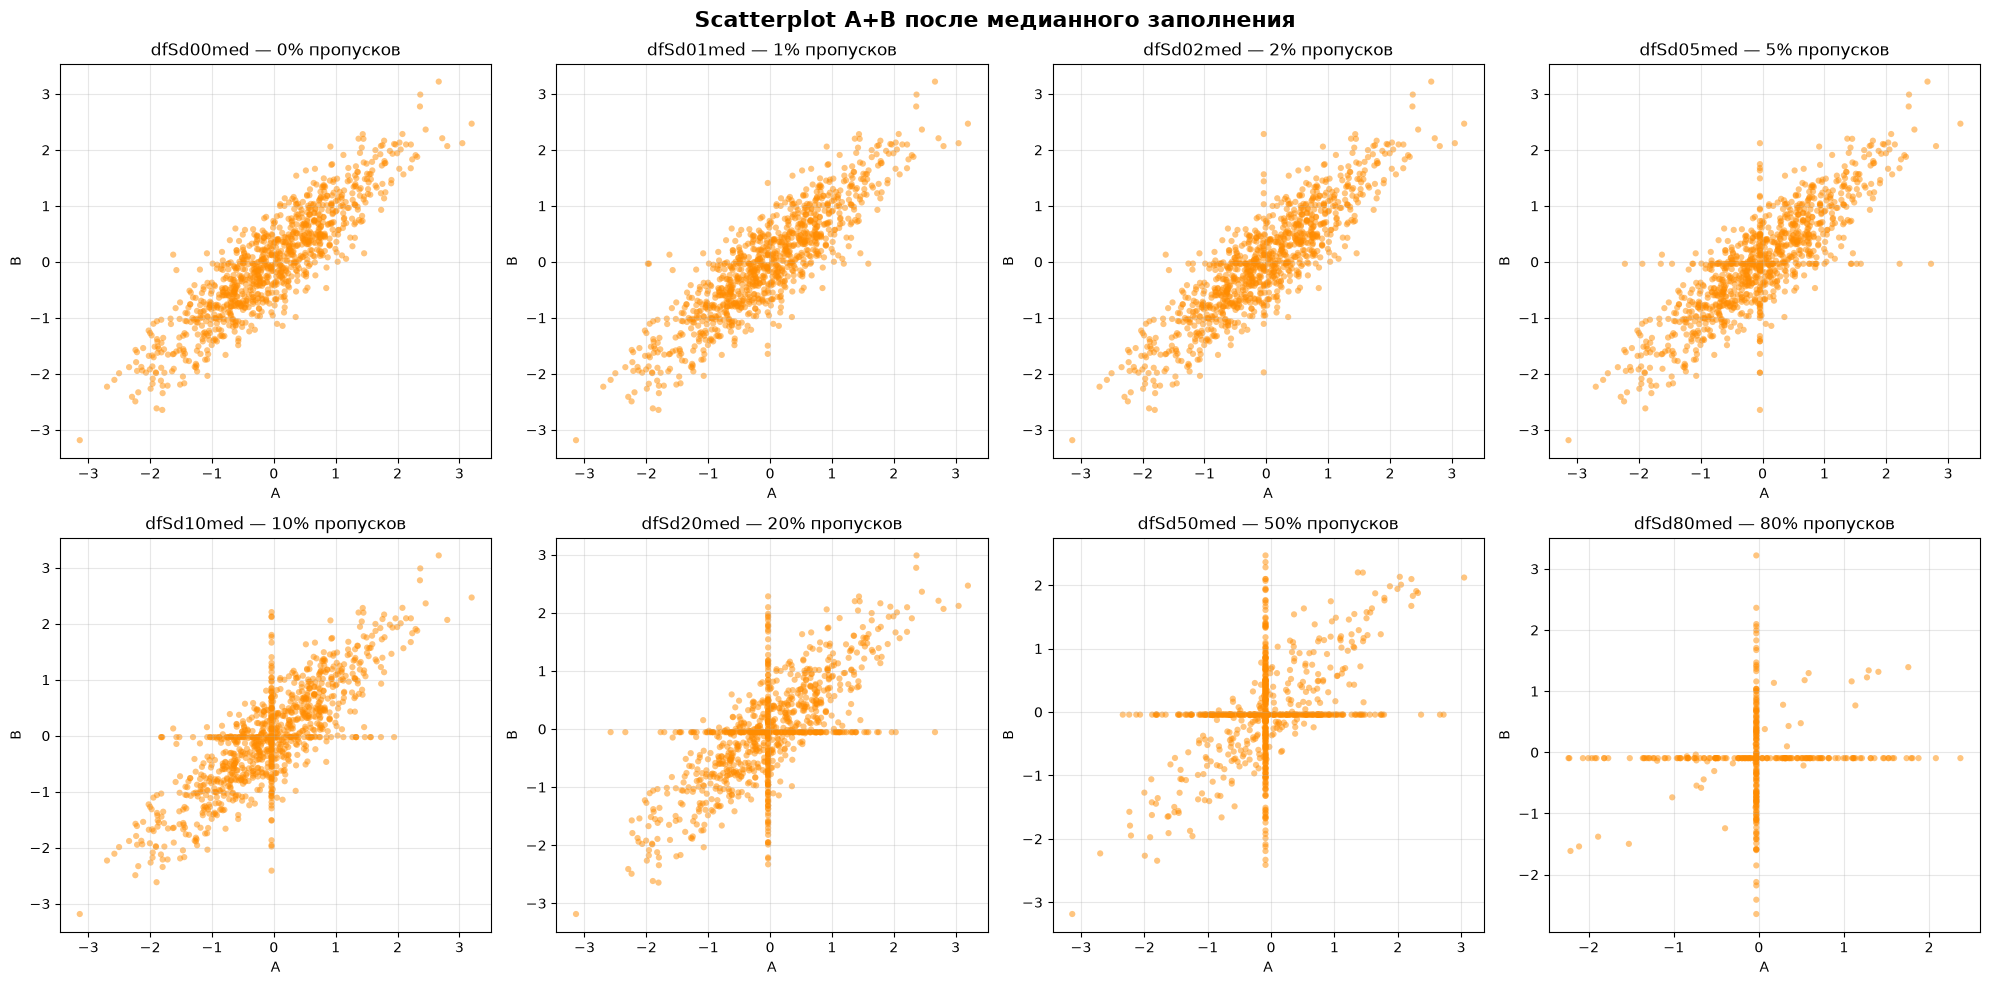

In [ ]:
datasets_med = {}

for name, df in datasets.items():
    df_med = df.copy()
    df_med[features] = df_med[features].fillna(df_med[features].median())
    datasets_med[f'{name}med'] = df_med


# Панно 2×4 scatterplot для выбранной пары A+B
x_feature, y_feature = 'A', 'B'

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Scatterplot A+B после медианного заполнения',
             fontsize=16, fontweight='bold')

for ax, (name, df), p in zip(axes.flat, datasets_med.items(), percentages):
    sns.scatterplot(data=df, x=x_feature, y=y_feature, ax=ax,
                    s=20, alpha=.5, color='darkorange', edgecolor='none')
    ax.set_title(f'{name} — {p}% пропусков')
    ax.grid(True, alpha=.3)

plt.tight_layout()
plt.show()


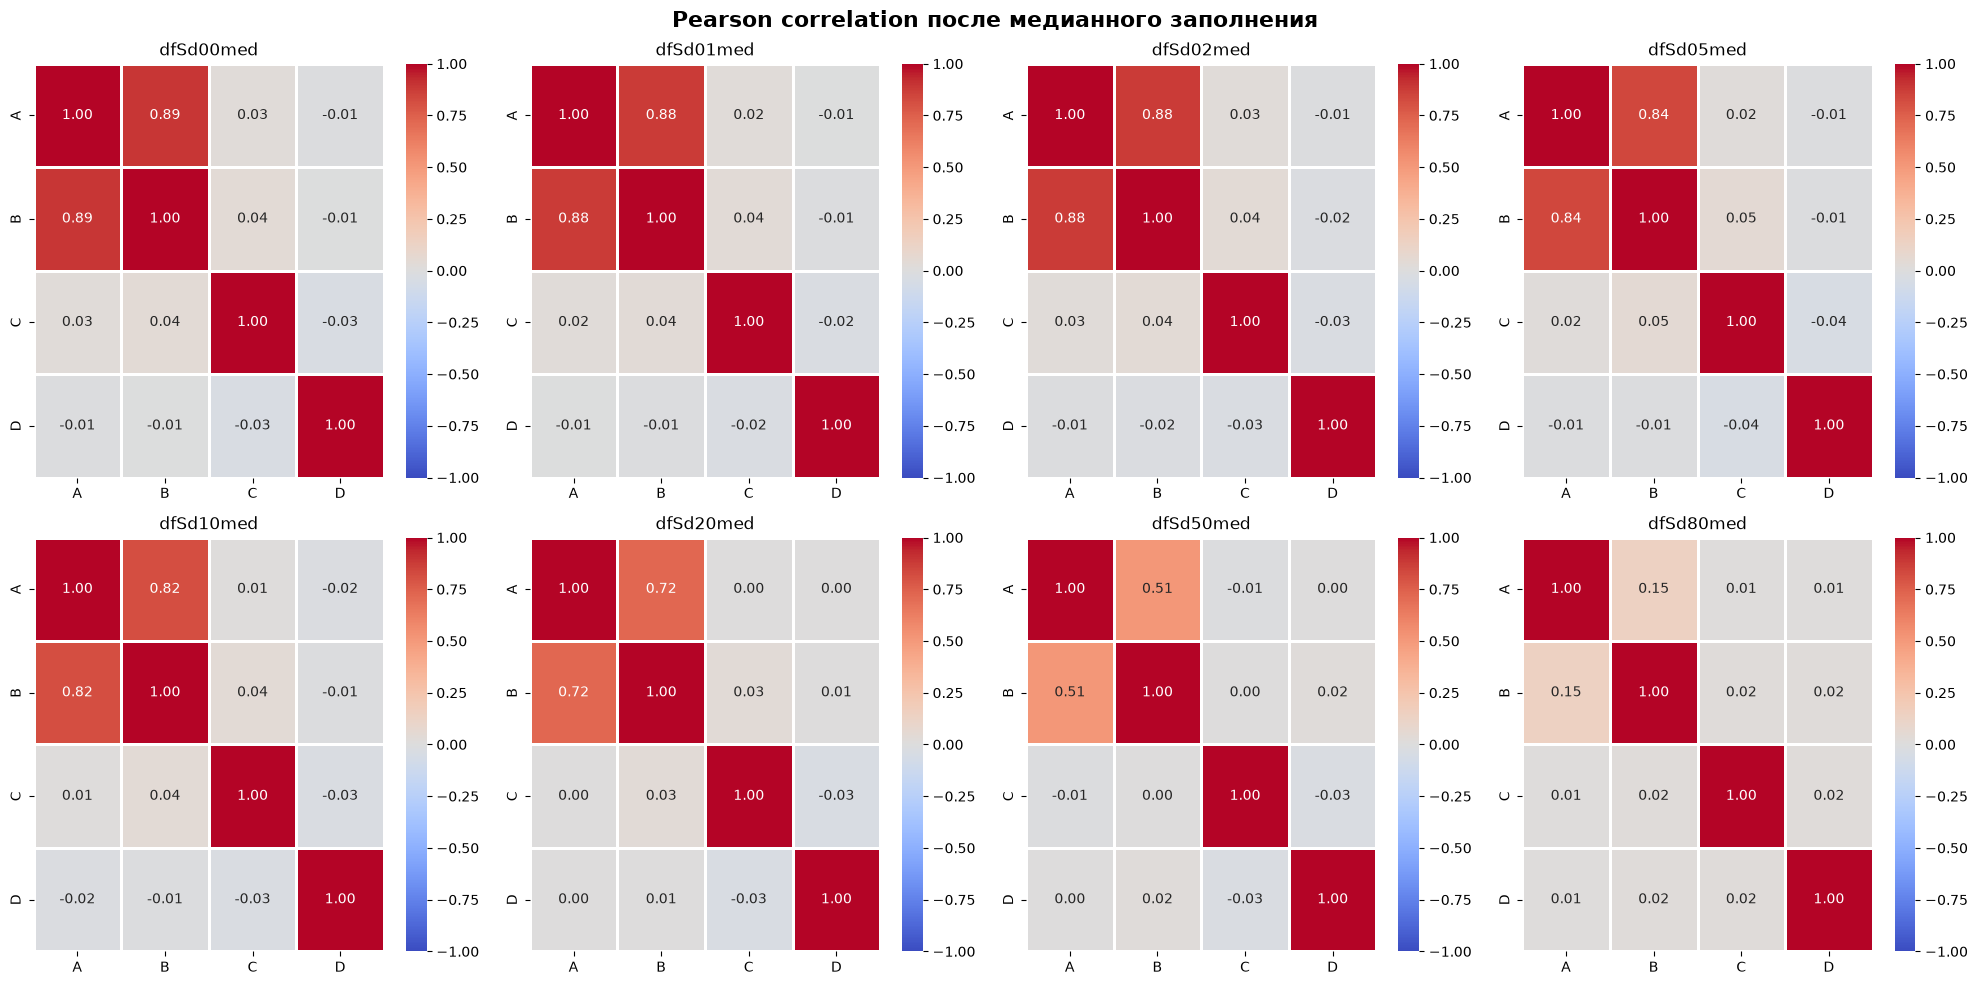

In [21]:
# Pearson heat-map для всех dfSdXXmed
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Pearson correlation после медианного заполнения',
             fontsize=16, fontweight='bold')

for ax, (name, df) in zip(axes.flat, datasets_med.items()):
    corr = df[features].corr(method='pearson')
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
                center=0, fmt='.2f', linewidths=1, linecolor='white', ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 8. Заполнение пропусков разными методами
На основе одного из датасетов  dfSdXX, выбранного  пользователем,  сгенерировать соответствующие  датасеты  dfSdXXname,  в  котором  пропуски  заполнены  следующими методами  (name):  
- медианами
- kNN-заполнением
- регрессионным  заполнением
- MICE-заполнением. 

Для  dfSd00,  выбранного dfSdXX и  каждого  из  датасетов  dfSdXXname вывести как heatmap корреляции Пирсона как в пункте [1.5], а также визуализировать две пары  признаков, выбираемые  пользователем (исходно A+B  и C+D), как два панно mxn рисунков scatterplot. 

/home/fedosdan2/miniconda3/envs/sdt/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/fedosdan2/miniconda3/envs/sdt/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


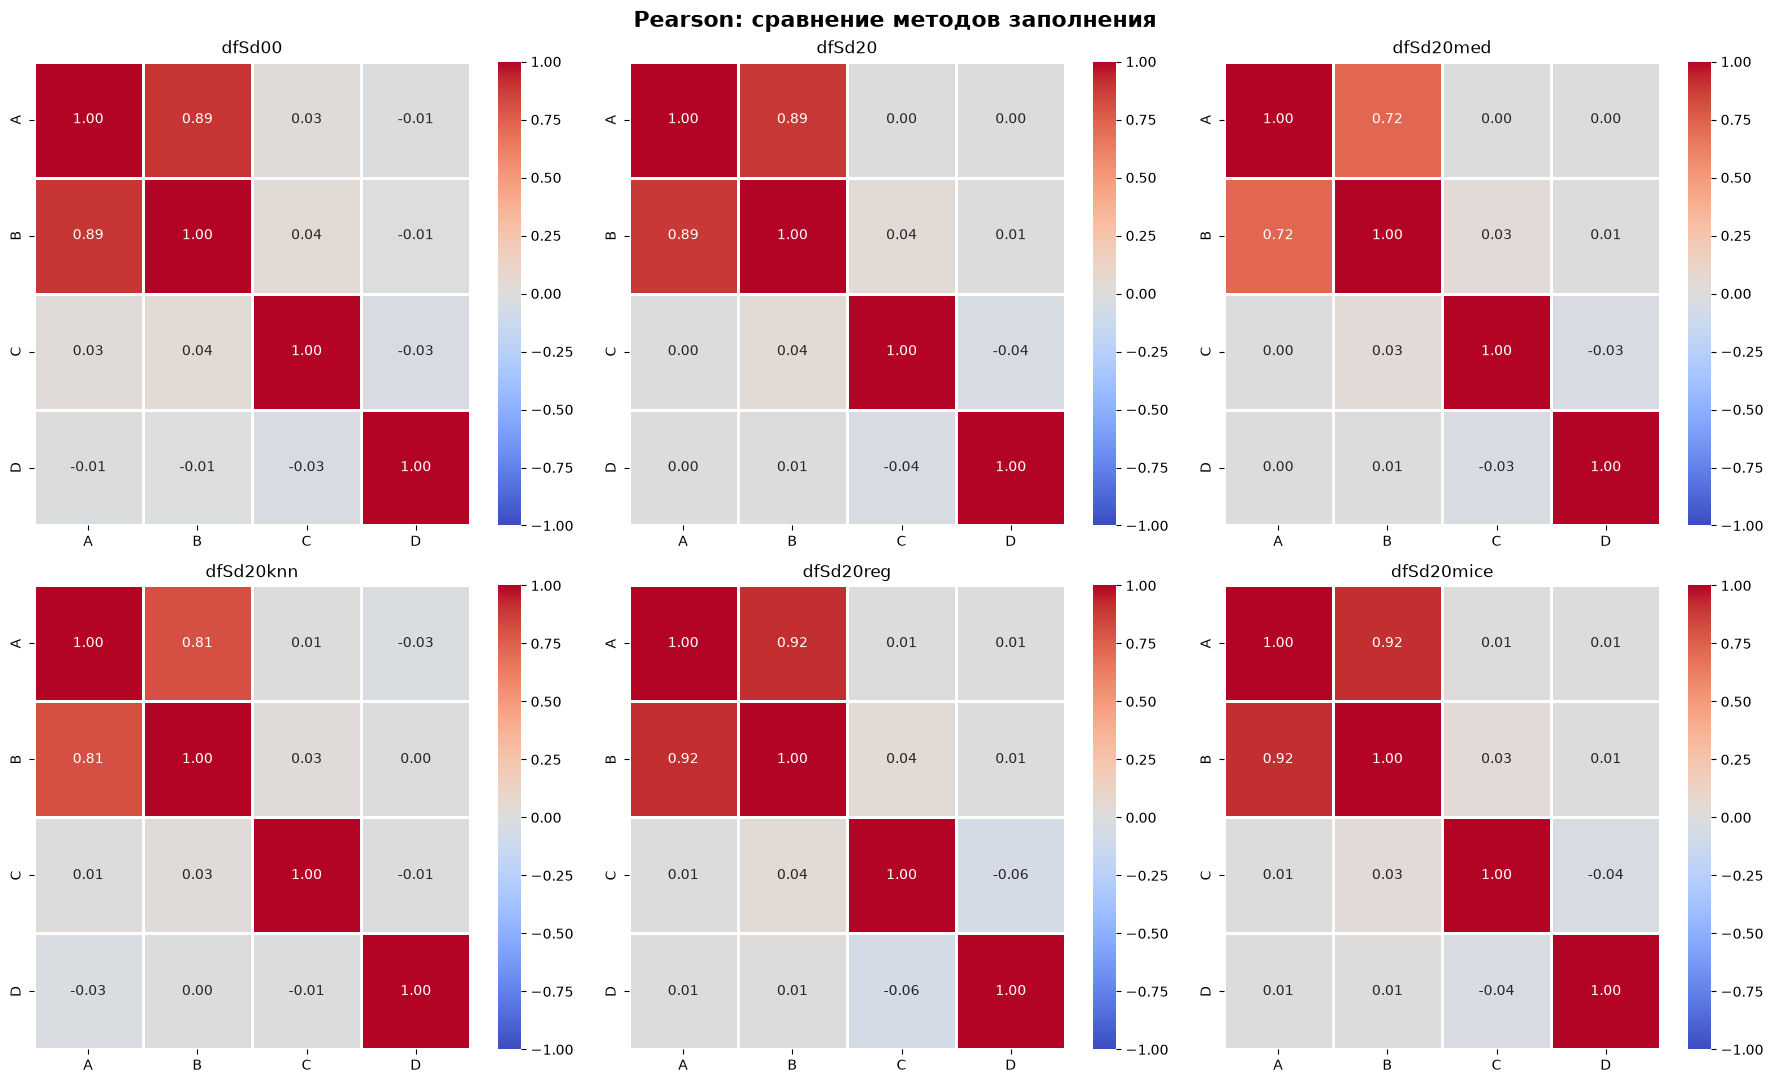

In [22]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LinearRegression, BayesianRidge

# Пользователь выбирает dfSdXX
CHOSEN_PERCENT = 20
features = ['A', 'B', 'C', 'D']
chosen_name = f'dfSd{CHOSEN_PERCENT:02d}'
dfSd_chosen = datasets[chosen_name]

# Исходный, выбранный с пропусками и заполненные варианты
imputed_datasets = {
    'dfSd00': dfS00,
    chosen_name: dfSd_chosen
}

# 1. Медиана
df_med = dfSd_chosen.copy()
df_med[features] = SimpleImputer(strategy='median').fit_transform(df_med[features])
imputed_datasets[f'{chosen_name}med'] = df_med

# 2. kNN
df_knn = dfSd_chosen.copy()
df_knn[features] = KNNImputer(n_neighbors=5).fit_transform(df_knn[features])
imputed_datasets[f'{chosen_name}knn'] = df_knn

# 3. Регрессионное заполнение
df_reg = dfSd_chosen.copy()
df_reg[features] = IterativeImputer(
    estimator=LinearRegression(), max_iter=10, random_state=42
).fit_transform(df_reg[features])
imputed_datasets[f'{chosen_name}reg'] = df_reg

# 4. MICE
df_mice = dfSd_chosen.copy()
df_mice[features] = IterativeImputer(
    estimator=BayesianRidge(), max_iter=10, random_state=42
).fit_transform(df_mice[features])
imputed_datasets[f'{chosen_name}mice'] = df_mice


# ----------------------------------------------------------
# Pearson heat-map для всех вариантов
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Pearson: сравнение методов заполнения', fontsize=16, fontweight='bold')

for ax, (name, df) in zip(axes.flat, imputed_datasets.items()):
    sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm',
                vmin=-1, vmax=1, center=0, fmt='.2f',
                linewidths=1, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()


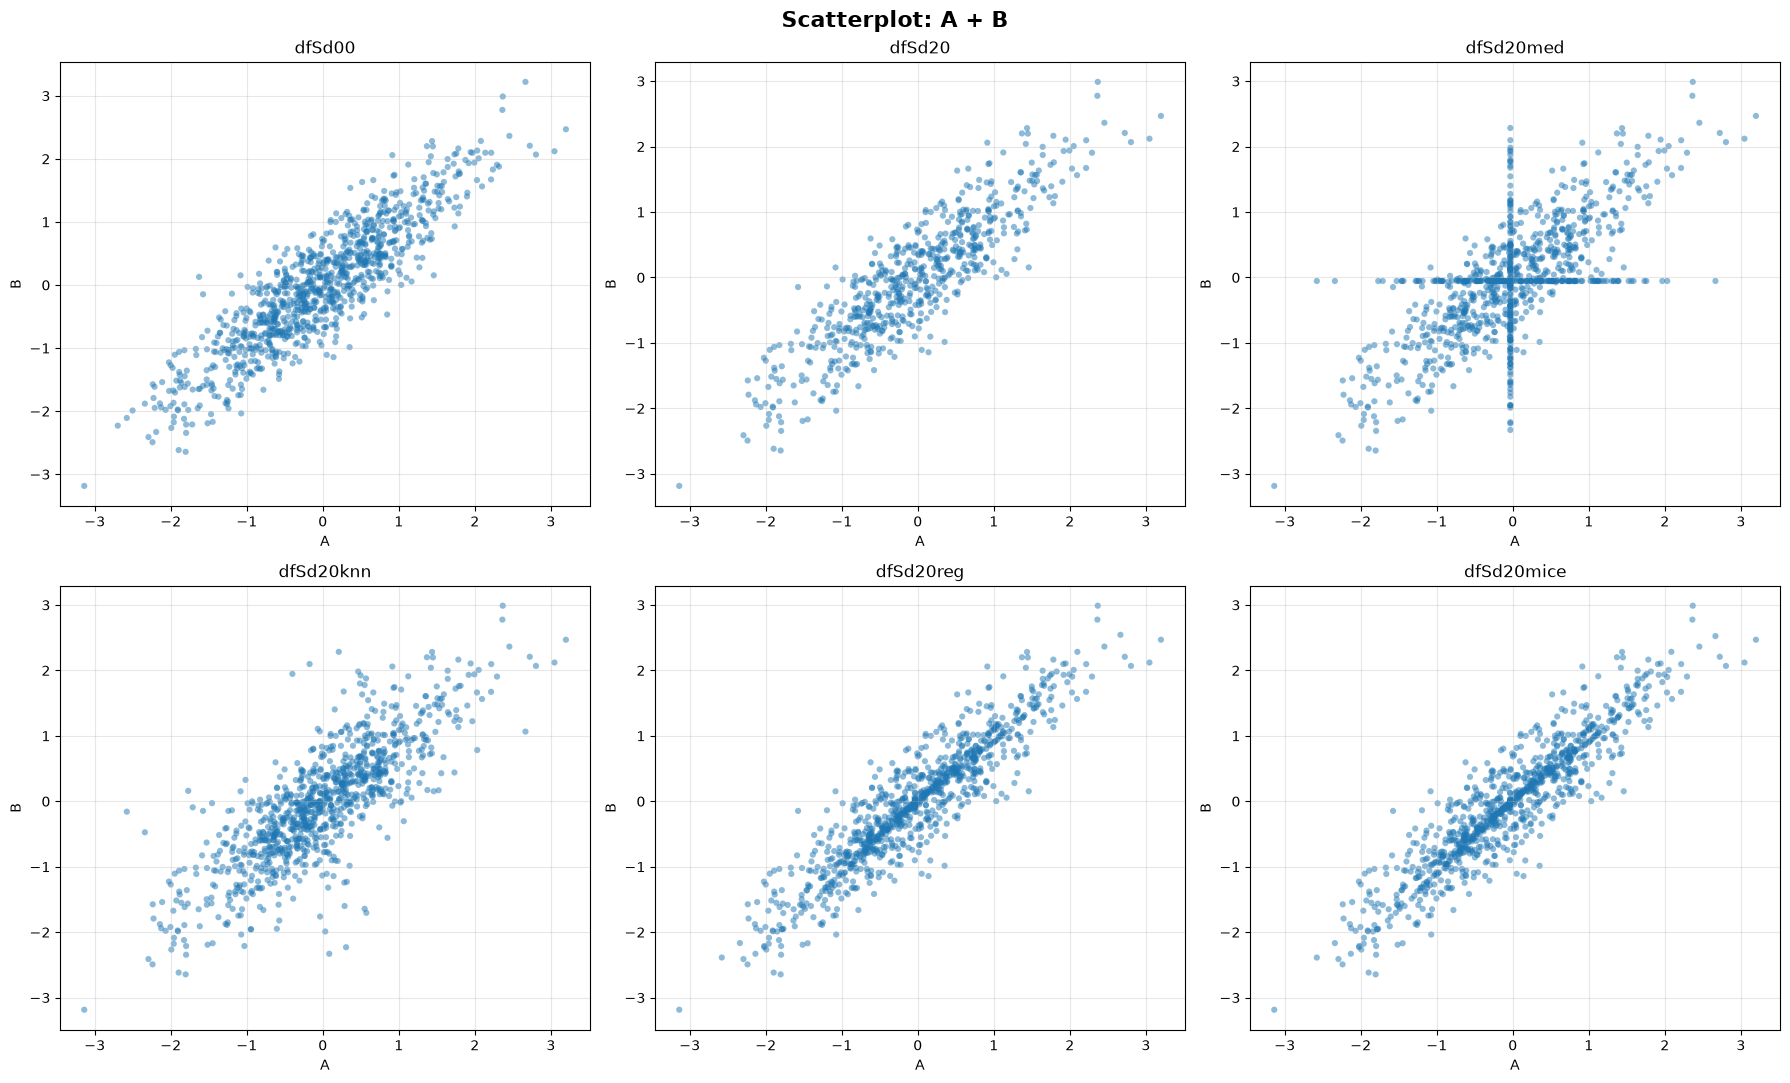

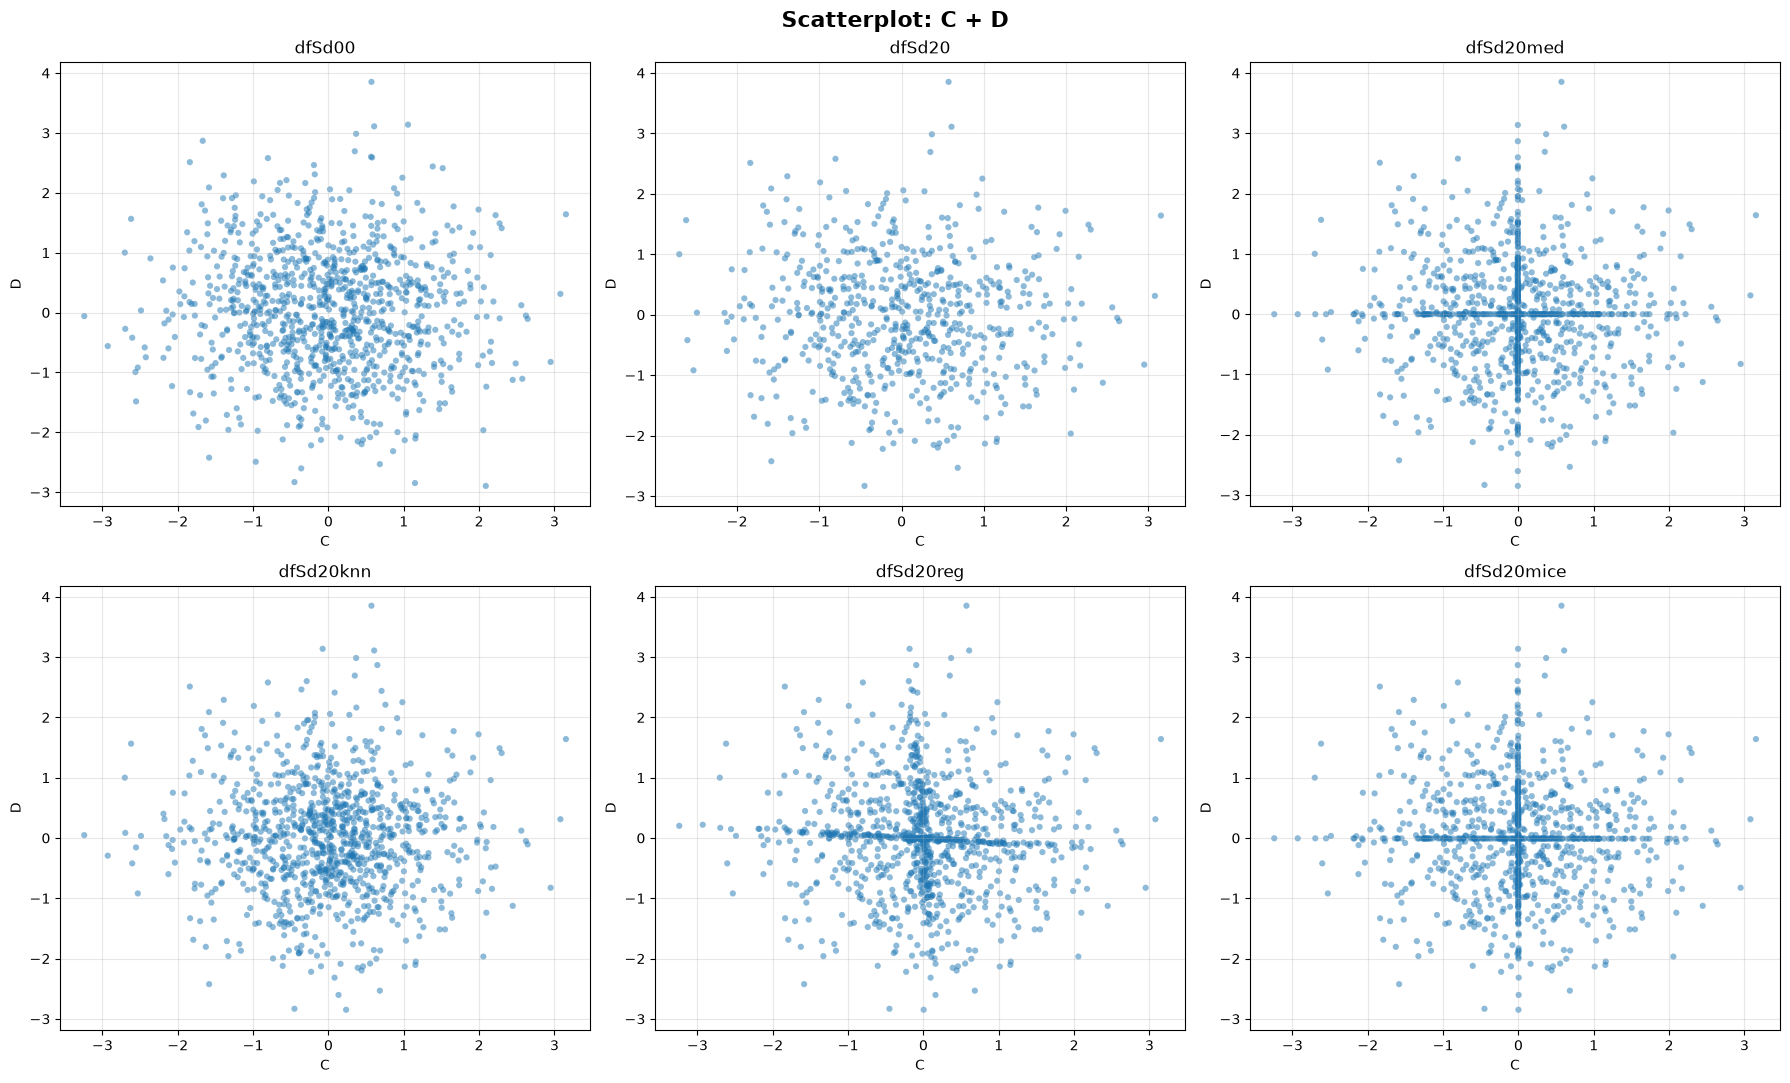

In [23]:
# ----------------------------------------------------------
# Scatterplot для выбранных пар A+B и C+D
# ----------------------------------------------------------
pairs = [('A', 'B'), ('C', 'D')]

for x, y in pairs:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(f'Scatterplot: {x} + {y}', fontsize=16, fontweight='bold')

    for ax, (name, df) in zip(axes.flat, imputed_datasets.items()):
        sns.scatterplot(data=df, x=x, y=y, ax=ax,
                        s=20, alpha=.5, edgecolor='none')
        ax.set_title(name)
        ax.grid(True, alpha=.3)

    plt.tight_layout()
    plt.show()

## 9. Визуализация с помощью Upset Plot
Для каждого из датасетов из пункта  [1.8], включая исходный dfSd00, выполнить в форме  Upset  plot  визуализацию:
- чисел  объектов  с  пропущенными  значениями  для всех  вариантов  группировки  пропусков  по  признакам
- чисел  объектов  с совпадающими значениями по признакам для всех вариантов группировки признаков. 

### Датасетом из пункта 8 был выбран  

dfSd00: пропущенных значений нет.
dfSd00: совпадающих значений нет.


/tmp/ipykernel_10848/1488766377.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


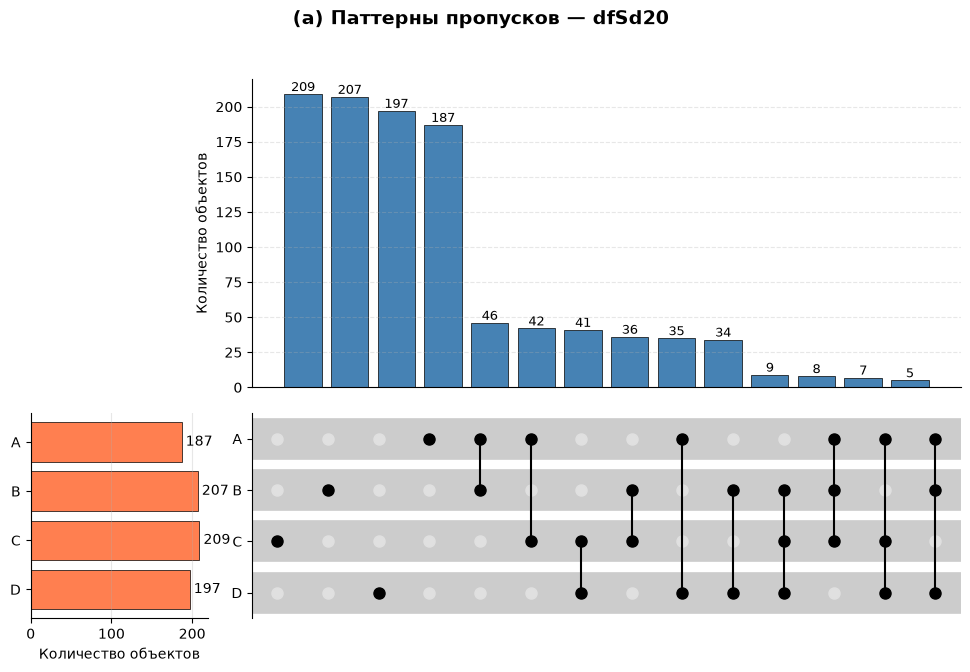

/tmp/ipykernel_10848/1488766377.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


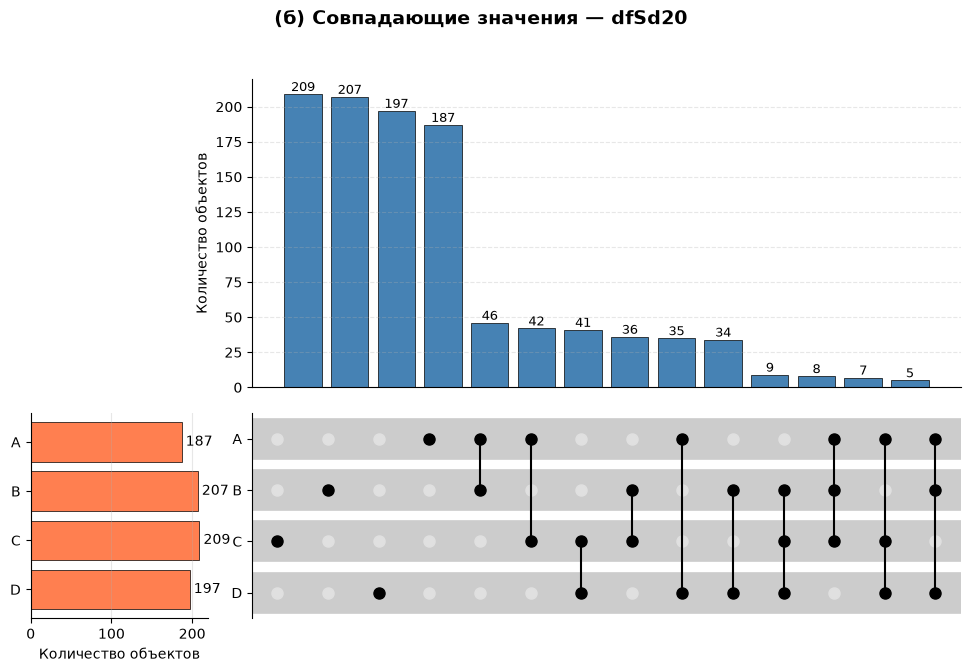

dfSd20med: пропущенных значений нет.


/tmp/ipykernel_10848/1488766377.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


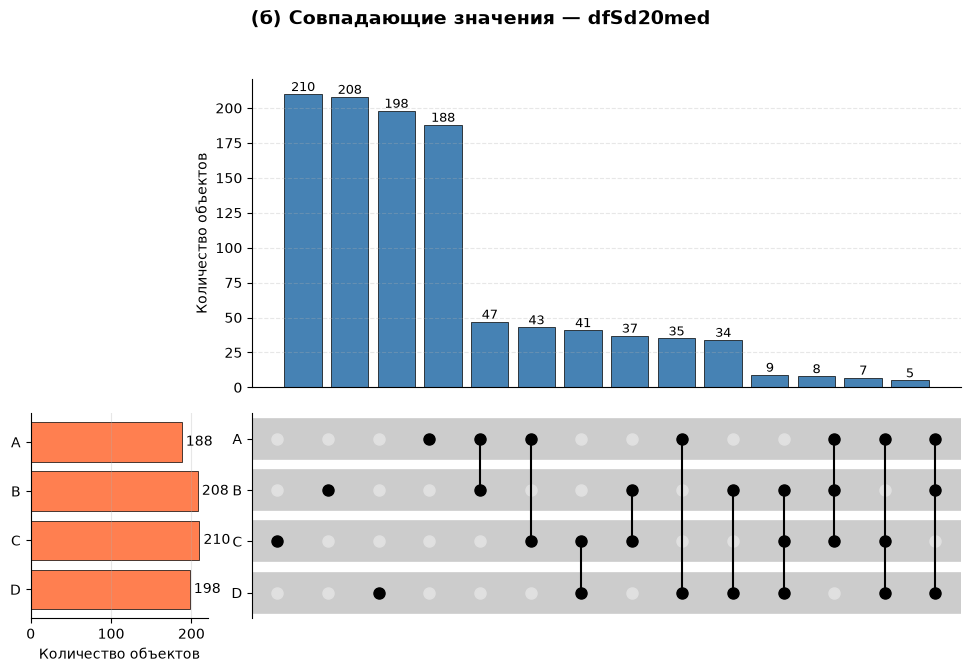

dfSd20knn: пропущенных значений нет.


/tmp/ipykernel_10848/1488766377.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


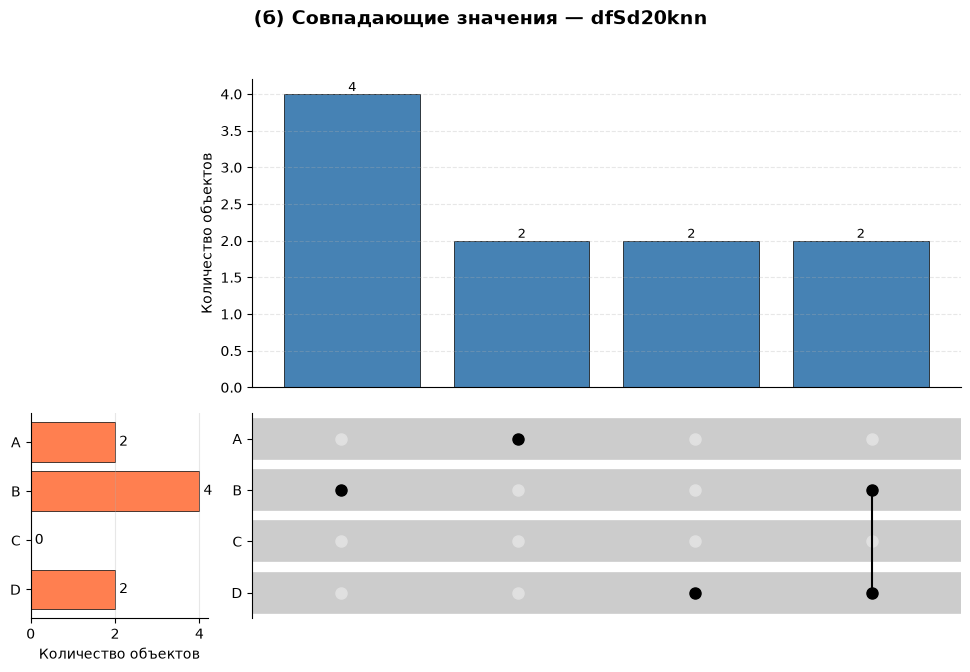

dfSd20reg: пропущенных значений нет.
dfSd20reg: совпадающих значений нет.
dfSd20mice: пропущенных значений нет.
dfSd20mice: совпадающих значений нет.


In [25]:
from itertools import combinations


def compute_intersections(df, indicator_cols):
    intersections = {}

    for r in range(1, len(indicator_cols) + 1):
        for combo in combinations(range(len(indicator_cols)), r):
            mask = df[[indicator_cols[i] for i in combo]].all(axis=1)
            if mask.sum() > 0:
                intersections[combo] = mask.sum()

    return intersections


def plot_upset(df, indicator_cols, abbreviations, intersections,
               max_intersections=15, figsize=(12, 7)):

    intersections = sorted(intersections.items(), key=lambda x: x[1], reverse=True)[:max_intersections]
    n_sets, n_intersections = len(indicator_cols), len(intersections)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, height_ratios=[3, 2],
                          width_ratios=[1, 4], hspace=.1, wspace=.1)

    ax_hist = fig.add_subplot(gs[0, 1])
    ax_matrix = fig.add_subplot(gs[1, 1])
    ax_sets = fig.add_subplot(gs[1, 0])

    # Гистограмма пересечений
    counts = [count for _, count in intersections]
    x = np.arange(n_intersections)

    bars = ax_hist.bar(x, counts, color='steelblue',
                       edgecolor='black', linewidth=.5)

    for bar, count in zip(bars, counts):
        ax_hist.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     str(count), ha='center', va='bottom', fontsize=9)

    ax_hist.set_ylabel('Количество объектов')
    ax_hist.set_xticks([])
    ax_hist.grid(axis='y', alpha=.3, linestyle='--')
    ax_hist.spines[['top', 'right']].set_visible(False)

    # Матрица пересечений
    for i in range(n_sets):
        ax_matrix.plot([-.5, n_intersections-.5], [i, i],
                       color='#CCCCCC', linewidth=30)

    for i in range(n_intersections):
        for j in range(n_sets):
            ax_matrix.plot(i, j, 'o', color='#E0E0E0', markersize=8)

    for i, (combo, _) in enumerate(intersections):
        for j in combo:
            ax_matrix.plot(i, j, 'o', color='black', markersize=8)

        if len(combo) > 1:
            ax_matrix.plot([i] * len(combo), sorted(combo),
                           color='black', linewidth=1.5)

    ax_matrix.set_xlim(-.5, n_intersections-.5)
    ax_matrix.set_ylim(-.5, n_sets-.5)
    ax_matrix.set_yticks(range(n_sets))
    ax_matrix.set_yticklabels(abbreviations)
    ax_matrix.invert_yaxis()
    ax_matrix.set_xticks([])
    ax_matrix.spines[['top', 'right', 'bottom']].set_visible(False)

    # Размеры множеств
    sizes = [df[col].sum() for col in indicator_cols]
    bars = ax_sets.barh(np.arange(n_sets), sizes,
                        color='coral', edgecolor='black', linewidth=.5)

    for bar, size in zip(bars, sizes):
        ax_sets.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                     f' {size}', va='center')

    ax_sets.set_yticks(range(n_sets))
    ax_sets.set_yticklabels(abbreviations)
    ax_sets.invert_yaxis()
    ax_sets.set_xlabel('Количество объектов')
    ax_sets.grid(axis='x', alpha=.3)
    ax_sets.spines[['top', 'right']].set_visible(False)

    return fig


features = ['A', 'B', 'C', 'D']
abbrevs = ['A', 'B', 'C', 'D']

for name, df in imputed_datasets.items():
    # ------------------------------------------------------
    # (а) Паттерны пропущенных значений
    # ------------------------------------------------------
    df_na = pd.DataFrame(index=df.index)

    for col in features:
        df_na[f'{col}_na'] = df[col].isna()

    na_cols = df_na.columns.tolist()
    intersections_na = compute_intersections(df_na, na_cols)

    if intersections_na:
        fig = plot_upset(df_na, na_cols, abbrevs, intersections_na)
        fig.suptitle(f'(а) Паттерны пропусков — {name}',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'{name}: пропущенных значений нет.')


    # ------------------------------------------------------
    # (б) Паттерны совпадающих значений
    # ------------------------------------------------------
    df_same = pd.DataFrame(index=df.index)

    for col in features:
        # True для всех объектов, значение признака которых повторяется
        df_same[f'{col}_same'] = df[col].duplicated(keep=False)

    same_cols = df_same.columns.tolist()
    intersections_same = compute_intersections(df_same, same_cols)

    if intersections_same:
        fig = plot_upset(df_same, same_cols, abbrevs, intersections_same)
        fig.suptitle(f'(б) Совпадающие значения — {name}',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'{name}: совпадающих значений нет.')


## 10. Работа с dfMNAR
- На основе исходного датасета dfS00 клонировать датасет dfMNAR, в котором для каждого  объекта  удалены  все  значения  призаков  C  и  D,  которые  меньше  признаковой медианы.  
- Выполнить для полученного датасета пункты [1.8] и [1.9]. 

dfMNAR:


,A,B,C,D,class
0,-0.824697,-0.143577,0.647689,NaN,1
1,0.056621,0.399828,1.579213,NaN,1
2,0.561727,0.353447,NaN,0.542560,1
3,-0.110104,-0.361567,NaN,NaN,1
4,1.302986,0.671385,NaN,0.314247,1



Пропуски:
A      0
B      0
C    500
D    500
dtype: int64


/home/fedosdan2/miniconda3/envs/sdt/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


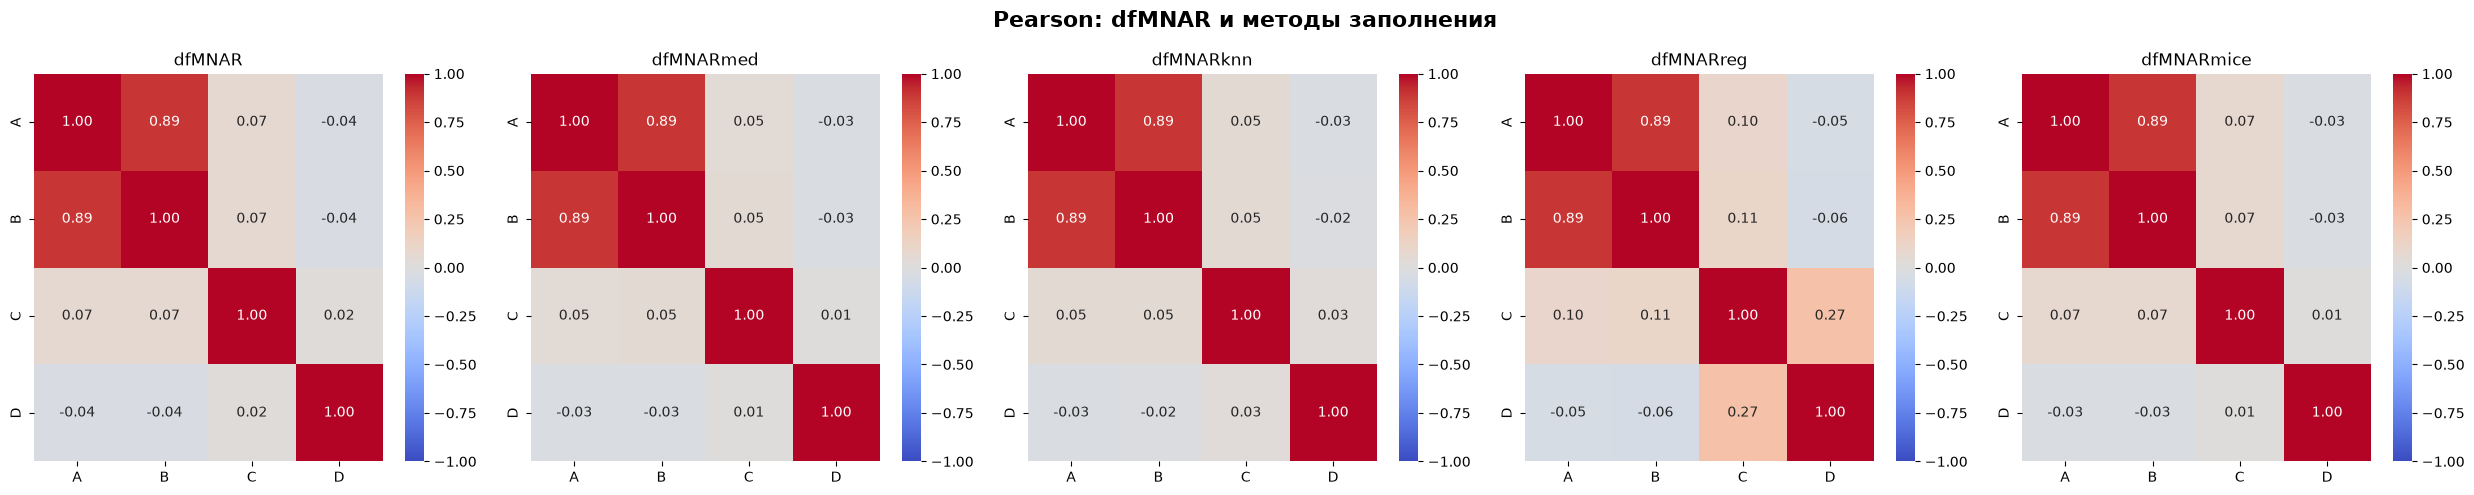

In [26]:
features = ['A', 'B', 'C', 'D']
pairs = [('A', 'B'), ('C', 'D')]

dfMNAR = dfS00.copy()
for col in ['C', 'D']:
    dfMNAR.loc[dfMNAR[col] < dfMNAR[col].median(), col] = np.nan

print('dfMNAR:')
display(dfMNAR.head())
print('\nПропуски:')
print(dfMNAR[features].isna().sum())


# ===== [1.8] Заполнение пропусков =====
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LinearRegression, BayesianRidge

mnar_datasets = {'dfMNAR': dfMNAR}

df = dfMNAR.copy()
df[features] = SimpleImputer(strategy='median').fit_transform(df[features])
mnar_datasets['dfMNARmed'] = df

df = dfMNAR.copy()
df[features] = KNNImputer(n_neighbors=5).fit_transform(df[features])
mnar_datasets['dfMNARknn'] = df

df = dfMNAR.copy()
df[features] = IterativeImputer(
    estimator=LinearRegression(), max_iter=10, random_state=42
).fit_transform(df[features])
mnar_datasets['dfMNARreg'] = df

df = dfMNAR.copy()
df[features] = IterativeImputer(
    estimator=BayesianRidge(), max_iter=10, random_state=42
).fit_transform(df[features])
mnar_datasets['dfMNARmice'] = df


# Pearson heatmap
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Pearson: dfMNAR и методы заполнения', fontsize=16, fontweight='bold')

for ax, (name, df) in zip(axes, mnar_datasets.items()):
    sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm',
                vmin=-1, vmax=1, center=0, fmt='.2f', ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()


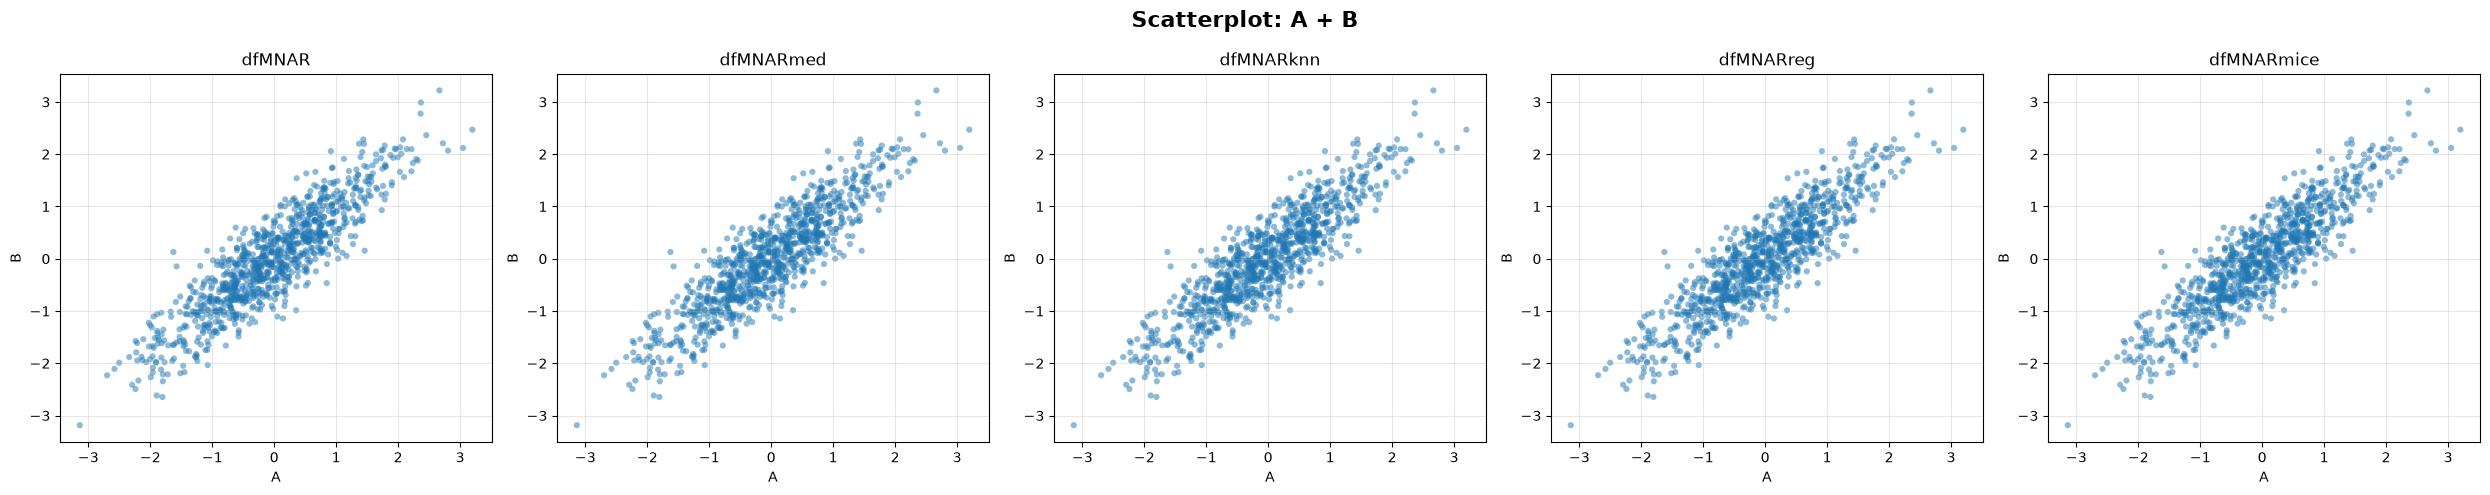

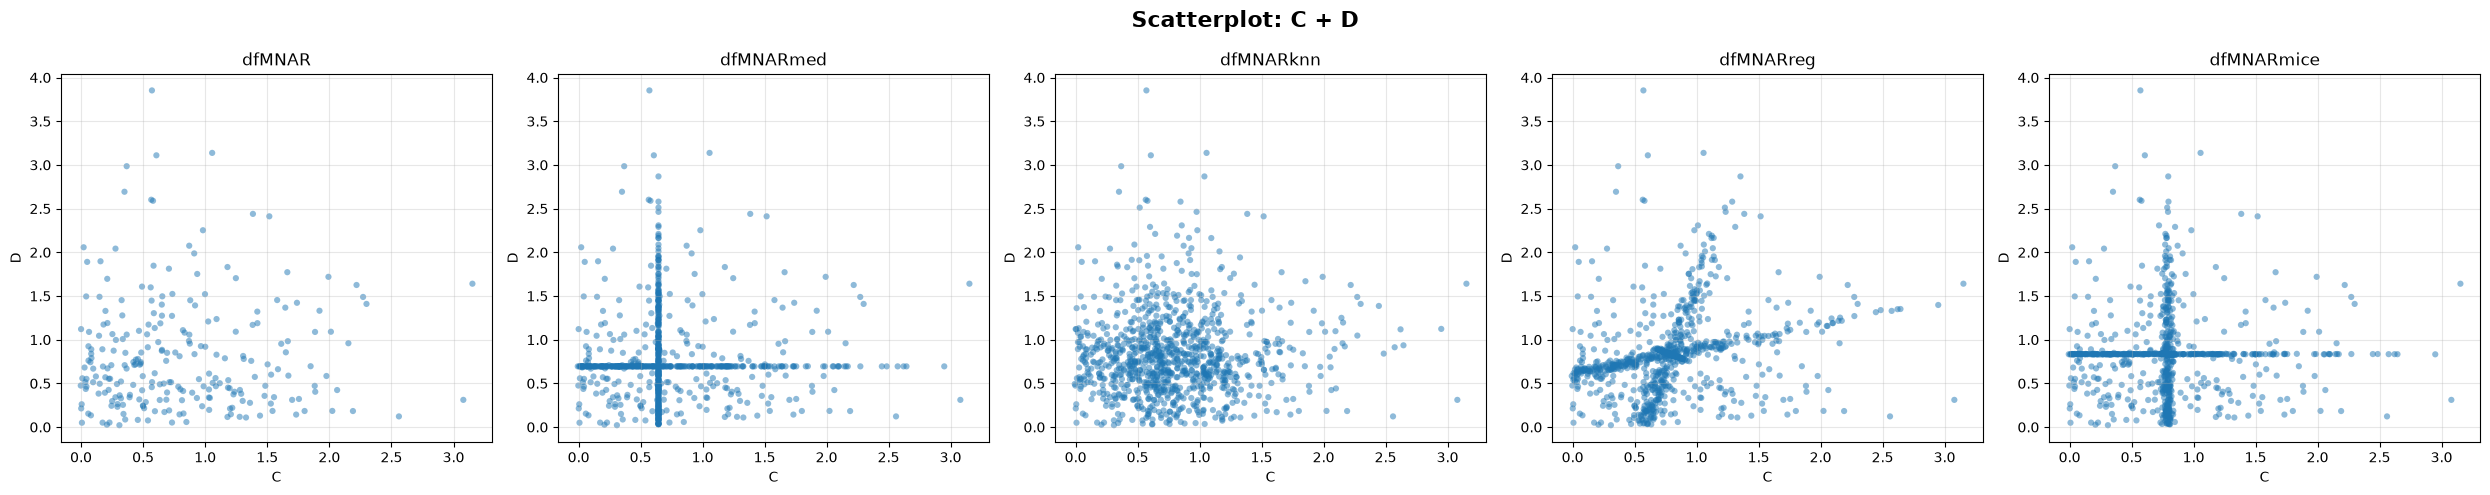

In [27]:
# Scatterplot для A+B и C+D
for x, y in pairs:
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(f'Scatterplot: {x} + {y}', fontsize=16, fontweight='bold')

    for ax, (name, df) in zip(axes, mnar_datasets.items()):
        sns.scatterplot(data=df, x=x, y=y, ax=ax,
                        s=20, alpha=.5, edgecolor='none')
        ax.set_title(name)
        ax.grid(True, alpha=.3)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_10848/1093127268.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


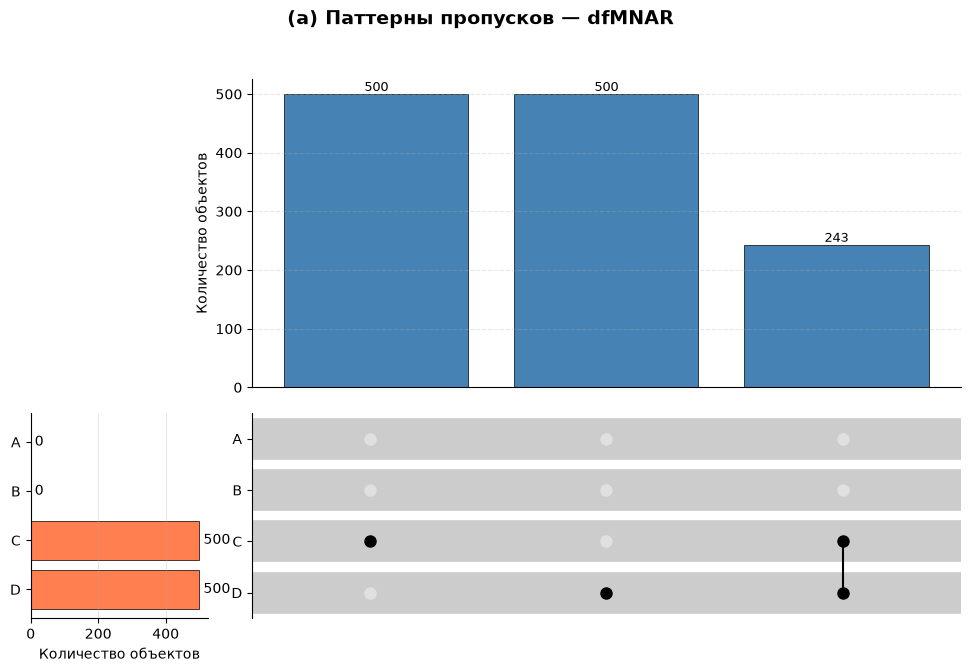

/tmp/ipykernel_10848/1093127268.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


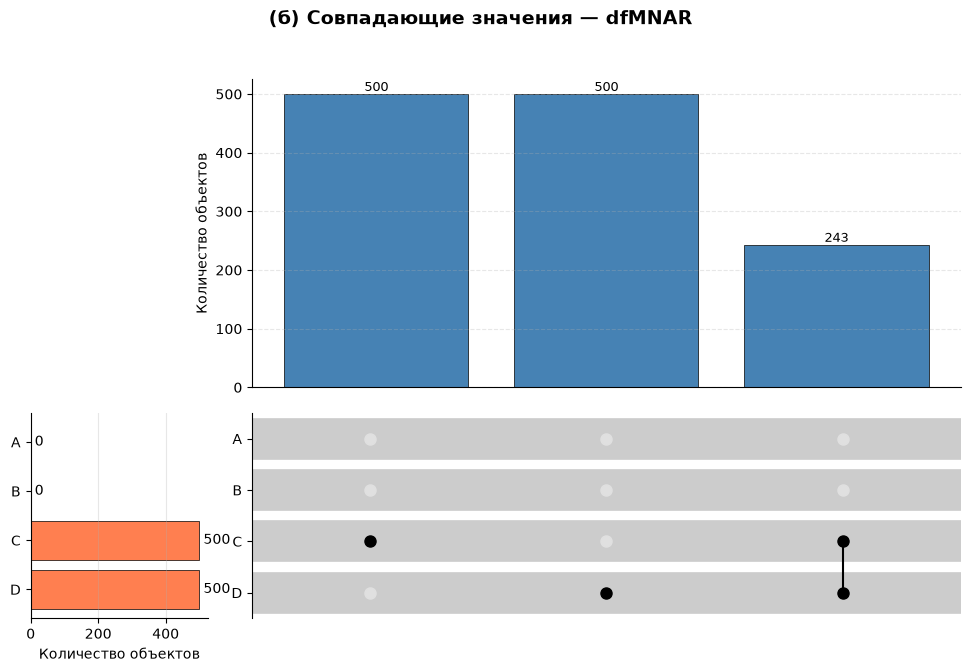

dfMNARmed: пропущенных значений нет.


/tmp/ipykernel_10848/1093127268.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


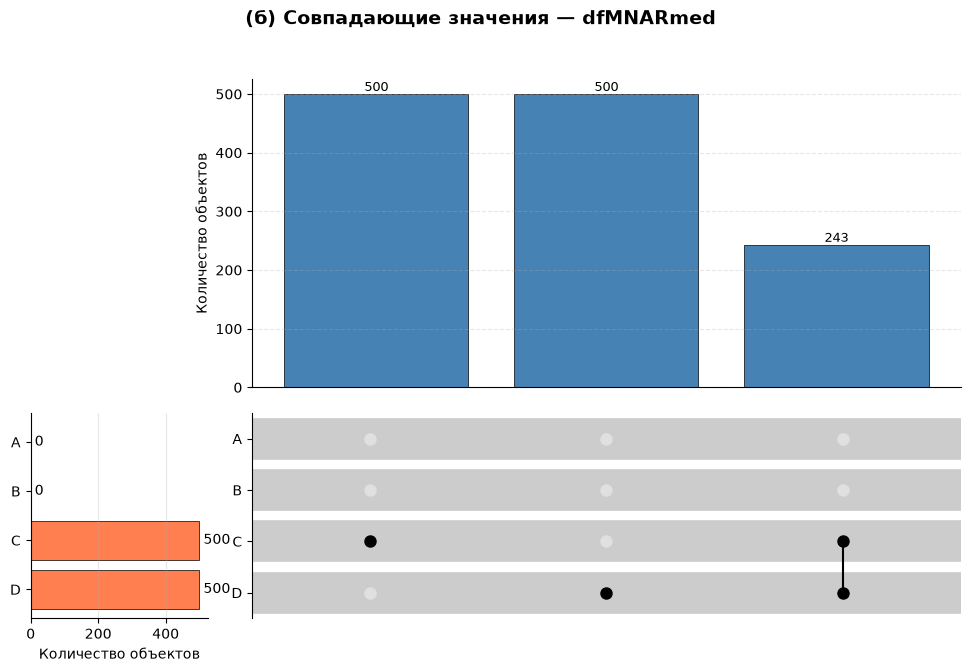

dfMNARknn: пропущенных значений нет.


/tmp/ipykernel_10848/1093127268.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


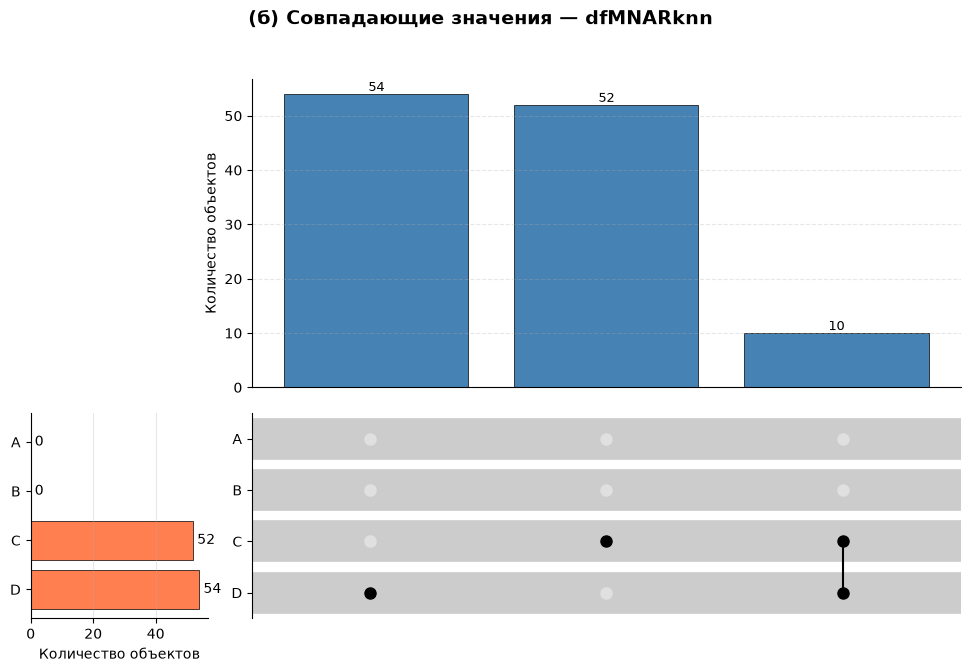

dfMNARreg: пропущенных значений нет.
dfMNARreg: совпадающих значений нет.
dfMNARmice: пропущенных значений нет.
dfMNARmice: совпадающих значений нет.


In [28]:
for name, df in mnar_datasets.items():

    # (а) Паттерны пропусков
    df_na = pd.DataFrame(index=df.index)
    for col in features:
        df_na[f'{col}_na'] = df[col].isna()

    na_cols = df_na.columns.tolist()
    intersections_na = compute_intersections(df_na, na_cols)

    if intersections_na:
        fig = plot_upset(df_na, na_cols, features, intersections_na)
        fig.suptitle(f'(а) Паттерны пропусков — {name}',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'{name}: пропущенных значений нет.')

    # (б) Объекты с совпадающими значениями
    df_same = pd.DataFrame(index=df.index)
    for col in features:
        df_same[f'{col}_same'] = df[col].duplicated(keep=False)

    same_cols = df_same.columns.tolist()
    intersections_same = compute_intersections(df_same, same_cols)

    if intersections_same:
        fig = plot_upset(df_same, same_cols, features, intersections_same)
        fig.suptitle(f'(б) Совпадающие значения — {name}',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'{name}: совпадающих значений нет.')
